# Chapter 10 - Deep Dream

Deep Dream *visualizes what a convnet sees* then *amplifies it*.

Idea: conv layers detect features (edges, lines, shapes). Deep Dream tweaks the input image so the activations of those layers are maxed via **gradient ascent**: we train *the image*, not the weights.

Standard implementations use a big pretrained ImageNet net. Here we stay offline & reproducible: **train a tiny CNN from scratch on synthetic blobs vs stripes**, then dream inside it. Same mechanism.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import matplotlib.pyplot as plt

import keras
from keras import layers, models
import tensorflow as tf

print("Keras", keras.__version__, "| TF", tf.__version__)

Keras 3.15.1 | TF 2.21.0


## 1. From-scratch dataset: blobs vs diagonal stripes

In [2]:
def make_images(n=900, size=64):
    imgs = np.zeros((n, size, size, 1), dtype="float32")
    labels = np.zeros(n, dtype="int32")
    yy, xx = np.mgrid[:size, :size]
    for i in range(n):
        if np.random.rand() < 0.5:                      # blob
            x0, y0 = np.random.randint(size//3, 2*size//3, 2)
            r = np.random.randint(4, 9)
            dist = (xx - x0)**2 + (yy - y0)**2
            mask = dist <= r*r
            imgs[i, mask, 0] = 1.0 - 0.8 * dist[mask] / (r*r)
            labels[i] = 0
        else:                                           # stripe
            imgs[i, :, :, 0] = (np.abs(xx - yy) < 3).astype("float32")
            labels[i] = 1
    idx = np.random.permutation(n)
    tr, te = idx[:int(0.6*n)], idx[int(0.6*n):]
    return (imgs[tr], labels[tr]), (imgs[te], labels[te])

(train_X, train_y), (test_X, test_y) = make_images()
print("train", train_X.shape, "test", test_X.shape)

train (540, 64, 64, 1) test (360, 64, 64, 1)


In [3]:
cnn = models.Sequential([
    layers.Input(shape=(64, 64, 1)),
    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(2, activation="softmax"),
])
cnn.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist = cnn.fit(train_X, train_y, validation_data=(test_X, test_y), epochs=8, verbose=0)
print("sanity accuracy (blobs vs stripes):", round(float(hist.history["val_accuracy"][-1]), 3))

sanity accuracy (blobs vs stripes): 1.0


## 2. The "dream" objective: maximize the deep conv activations

In [4]:
conv_target = cnn.layers[1]  # second Conv2D
# use the CNN's first layer input as the symbolic input (Keras 3 safe)
dream_model = models.Model(inputs=cnn.layers[0].input, outputs=conv_target.output)
print("dreaming on:", conv_target.name, "output", conv_target.output.shape)

dreaming on: conv2d_1 output (None, 64, 64, 32)


In [5]:
def gradient_ascent(image0, steps=40, step_size=0.05):
    image = tf.Variable(tf.convert_to_tensor(image0, dtype="float32"))
    for _ in range(steps):
        with tf.GradientTape() as tape:
            tape.watch(image)
            acts = dream_model(image)
            loss = tf.reduce_mean(tf.square(acts))
        grads = tape.gradient(loss, image)
        if grads is None:
            break
        image.assign_add(step_size * grads)
    return tf.clip_by_value(image, 0.0, 1.0).numpy()

## 3. Apply it: a mixed seed blossoms into a pure pattern

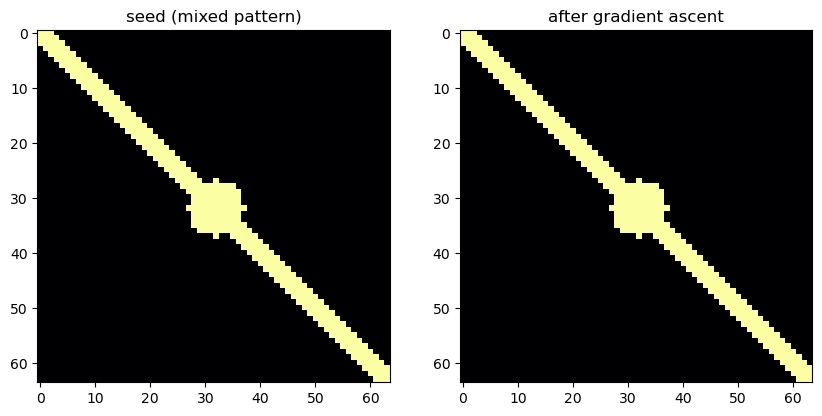

In [6]:
seed = np.zeros((1, 64, 64, 1), dtype="float32")
yy, xx = np.mgrid[:64, :64]
blob = (xx - 32) ** 2 + (yy - 32) ** 2 <= 25
seed[0, blob, 0] = 1.0
seed[0, ~blob, 0] = (np.abs(xx - yy) < 3)[~blob].astype("float32")

out = gradient_ascent(seed, steps=40)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(seed[0, ..., 0], cmap="inferno"); ax[0].set_title("seed (mixed pattern)")
ax[1].imshow(out[0, ..., 0], cmap="inferno"); ax[1].set_title("after gradient ascent")
plt.show()

## 4. Octave dreaming — detail at multiple resolutions

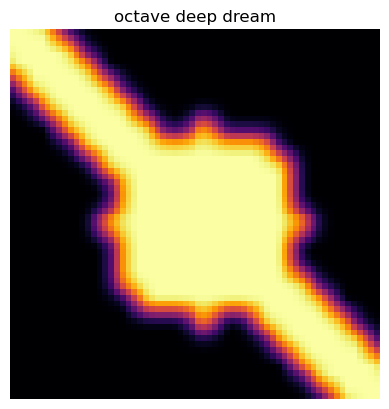

In [7]:
def octave_dream(image0, steps=12, step_size=0.04, octaves=3, scale=1.5):
    # works on a fixed 64x64 canvas: upscale, center-crop back to 64, then dream
    img = tf.convert_to_tensor(image0, dtype="float32")          # (1,64,64,1)
    for _ in range(octaves):
        big = tf.image.resize(img, (int(64*scale), int(64*scale)))
        # center crop to 64
        off = (int(64*scale) - 64) // 2
        img = big[:, off:off+64, off:off+64, :]
        var = tf.Variable(img)
        for _ in range(steps):
            with tf.GradientTape() as tape:
                tape.watch(var)
                acts = dream_model(var)
                loss = tf.reduce_mean(tf.square(acts))
            grads = tape.gradient(loss, var)
            if grads is not None:
                var.assign_add(step_size * grads)
        img = tf.clip_by_value(var, 0.0, 1.0)
    return img.numpy()

dreamed = octave_dream(seed)
plt.imshow(dreamed[0, ..., 0], cmap="inferno"); plt.axis("off"); plt.title("octave deep dream")
plt.show()

## Recap
- Deep Dream = gradient *ascent* on the image to maximize deep-feature activations.
- Reveals what the CNN learned (blobs/stripes; on ImageNet: animals, anatomy).
- The same "gradient-on-input" trick powers feature visualization and adversarial examples.